<a href="https://colab.research.google.com/github/Fardous-bp/CNS-doped-Al-interconnect-alloy/blob/main/CNS_Al_18_75__(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install matcalc

!pip install matgl
!pip install seekpath

!pip install crystal-toolkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.9/579.9 kB 16.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 598.8/598.8 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 850.5/850.5 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
from pymatgen.core import Structure
my_cif_file = "CuNi2Sn.cif"

if os.path.exists(my_cif_file):
    my_structure = Structure.from_file(my_cif_file)
    print(f"SUCCESS: {my_cif_file} loaded successfully.")
    print(my_structure)
else:
    print(f"ERROR: File '{my_cif_file}' not found. Please check the name in your Colab files tab.")

SUCCESS: CuNi2Sn.cif loaded successfully.
Full Formula (Cu4 Ni8 Sn4)
Reduced Formula: CuNi2Sn
abc   :   5.975124   5.975124   5.975124
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (16)
  #  SP       a     b     c
---  ----  ----  ----  ----
  0  Cu    0     0     0
  1  Cu    0     0.5   0.5
  2  Cu    0.5   0     0.5
  3  Cu    0.5   0.5   0
  4  Ni    0.25  0.75  0.75
  5  Ni    0.25  0.25  0.75
  6  Ni    0.25  0.25  0.25
  7  Ni    0.25  0.75  0.25
  8  Ni    0.75  0.75  0.25
  9  Ni    0.75  0.25  0.25
 10  Ni    0.75  0.25  0.75
 11  Ni    0.75  0.75  0.75
 12  Sn    0     0     0.5
 13  Sn    0     0.5   0
 14  Sn    0.5   0     0
 15  Sn    0.5   0.5   0.5


In [3]:
# The value 0.2 adds random noise (in Angstroms) to the atomic sites
cuni2sn_perturbed = my_structure.copy()
cuni2sn_perturbed.perturb(0.2)

# 2. Expand the lattice volume
# Multiplying by 1.2 increases the total cell volume by 20%
cuni2sn_perturbed.scale_lattice(my_structure.volume * 1.2)

# 3. View the results
print("Perturbed CuNi2Sn Structure:")
print(cuni2sn_perturbed)
cuni2sn_perturbed

Perturbed CuNi2Sn Structure:
Full Formula (Cu4 Ni8 Sn4)
Reduced Formula: CuNi2Sn
abc   :   6.349517   6.349517   6.349517
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (16)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Cu    0.01023   0.00975   0.998328
  1  Cu    0.983167  0.484116  0.490815
  2  Cu    0.506399  0.002374  0.506186
  3  Cu    0.504895  0.497334  0.989026
  4  Ni    0.223866  0.745608  0.757103
  5  Ni    0.244662  0.239479  0.774863
  6  Ni    0.266562  0.259746  0.254588
  7  Ni    0.250191  0.748216  0.2477
  8  Ni    0.733543  0.737359  0.260247
  9  Ni    0.740699  0.233272  0.253488
 10  Ni    0.726613  0.228563  0.751221
 11  Ni    0.730815  0.772823  0.744402
 12  Sn    0.000713  0.998238  0.498991
 13  Sn    0.001387  0.486315  0.011045
 14  Sn    0.509818  0.00186   0.01517
 15  Sn    0.483193  0.516706  0.510046


Structure Summary
Lattice
    abc : 6.349516720528679 6.349516720528679 6.349516720528679
 angles : 90.0 90.0 90.0
 volume : 255.98941833973996
      A : 6.349516720528679 0.0 3.887957663964023e-16
      B : 1.0210801652782683e-15 6.349516720528679 3.887957663964023e-16
      C : 0.0 0.0 6.349516720528679
    pbc : True True True
PeriodicSite: Cu0 (Cu) (0.06495, 0.06191, 6.339) [0.01023, 0.00975, 0.9983]
PeriodicSite: Cu1 (Cu) (6.243, 3.074, 3.116) [0.9832, 0.4841, 0.4908]
PeriodicSite: Cu2 (Cu) (3.215, 0.01507, 3.214) [0.5064, 0.002374, 0.5062]
PeriodicSite: Cu3 (Cu) (3.206, 3.158, 6.28) [0.5049, 0.4973, 0.989]
PeriodicSite: Ni4 (Ni) (1.421, 4.734, 4.807) [0.2239, 0.7456, 0.7571]
PeriodicSite: Ni5 (Ni) (1.553, 1.521, 4.92) [0.2447, 0.2395, 0.7749]
PeriodicSite: Ni6 (Ni) (1.693, 1.649, 1.617) [0.2666, 0.2597, 0.2546]
PeriodicSite: Ni7 (Ni) (1.589, 4.751, 1.573) [0.2502, 0.7482, 0.2477]
PeriodicSite: Ni8 (Ni) (4.658, 4.682, 1.652) [0.7335, 0.7374, 0.2602]
PeriodicSite: Ni9 (Ni) (4.703, 

In [4]:
import matcalc
from matcalc.utils import UNIVERSAL_CALCULATORS

import pprint
pprint.pprint(list(UNIVERSAL_CALCULATORS))  # calculators that come with bundled with matgl

[<UNIVERSAL_CALCULATORS.CHGNet-MatPES-PBE-2025.2.10: 'CHGNet-MatPES-PBE-2025.2.10'>,
 <UNIVERSAL_CALCULATORS.CHGNet-MatPES-r2SCAN-2025.2.10: 'CHGNet-MatPES-r2SCAN-2025.2.10'>,
 <UNIVERSAL_CALCULATORS.DPA3-LAM-2025.3.14: 'DPA3-LAM-2025.3.14'>,
 <UNIVERSAL_CALCULATORS.GRACE-1L-OAM: 'GRACE-1L-OAM'>,
 <UNIVERSAL_CALCULATORS.GRACE-2L-MPtrj: 'GRACE-2L-MPtrj'>,
 <UNIVERSAL_CALCULATORS.GRACE-2L-OAM: 'GRACE-2L-OAM'>,
 <UNIVERSAL_CALCULATORS.GRACE-2L-OMAT: 'GRACE-2L-OMAT'>,
 <UNIVERSAL_CALCULATORS.M3GNet-MatPES-PBE-2025.1: 'M3GNet-MatPES-PBE-2025.1'>,
 <UNIVERSAL_CALCULATORS.MACE-MP-0-large: 'MACE-MP-0-large'>,
 <UNIVERSAL_CALCULATORS.MACE-MP-0-medium: 'MACE-MP-0-medium'>,
 <UNIVERSAL_CALCULATORS.MACE-MP-0-small: 'MACE-MP-0-small'>,
 <UNIVERSAL_CALCULATORS.MACE-MP-0b-medium: 'MACE-MP-0b-medium'>,
 <UNIVERSAL_CALCULATORS.MACE-MP-0b-small: 'MACE-MP-0b-small'>,
 <UNIVERSAL_CALCULATORS.MACE-MP-0b2-large: 'MACE-MP-0b2-large'>,
 <UNIVERSAL_CALCULATORS.MACE-MP-0b2-medium: 'MACE-MP-0b2-medium'>,
 <UNIVE

In [5]:
from matcalc.utils import MODEL_ALIASES
pprint.pprint(MODEL_ALIASES)  # list all "aliased" models

{'chgnet': 'CHGNet-MatPES-PBE-2025.2.10',
 'chgnet-matpes-pbe-2025.2.10-2.7m-pes': 'CHGNet-MatPES-PBE-2025.2.10',
 'chgnet-pes-matpes-pbe-2025.2.10': 'CHGNet-MatPES-PBE-2025.2.10',
 'chgnet-pes-matpes-r2scan-2025.2.10': 'CHGNet-MatPES-r2SCAN-2025.2.10',
 'deepmd': 'DPA3-LAM-2025.3.14',
 'fairchem': 'UMA-S-1.2',
 'grace': 'GRACE-2L-OAM',
 'm3gnet': 'M3GNet-MatPES-PBE-2025.1',
 'm3gnet-pes-matpes-pbe-2025.1': 'M3GNet-MatPES-PBE-2025.1',
 'mace': 'MACE-MPA-0-medium',
 'mattersim': 'MatterSim-v1.0.0-1M',
 'orb': 'ORB-v2',
 'pbe': 'TensorNet-MatPES-PBE-2025.2',
 'petmad': 'PETMAD-1.0.0',
 'r2scan': 'TensorNet-MatPES-r2SCAN-2025.2',
 'sevennet': 'SevenNet-0',
 'tensornet': 'TensorNet-MatPES-PBE-2025.2',
 'tensornet-pes-matpes-pbe-2025.2': 'TensorNet-MatPES-PBE-2025.2',
 'tensornet-pes-matpes-r2scan-2025.2': 'TensorNet-MatPES-r2SCAN-2025.2',
 'tensorpotential': 'GRACE-2L-OAM',
 'uma': 'UMA-S-1.2'}


In [6]:
calculator_pbe = matcalc.load_fp("pbe")
# calculator_pbe = matcalc.load_fp("TensorNet-MatPES-PBE-v2025.1-PES")

model.pt: reconstructing file:   0%|          |  0.00B / 4.50kB            

model.pt: downloading bytes:           |  0.00B            

state.pt: reconstructing file:   0%|          |  0.00B / 3.40MB            

state.pt: downloading bytes:           |  0.00B            

model.json:   0%|          | 0.00/5.30k [00:00<?, ?B/s]

In [7]:
# Initialize the Relaxer exactly like the notebook
relax_calc = matcalc.RelaxCalc(
    calculator_pbe,
    optimizer="FIRE",
    relax_atoms=True,
    relax_cell=True,
)

# This should now complete in 1-3 minutes
print("Starting structural optimization...")
data = relax_calc.calc(cuni2sn_perturbed)

# Output results
print(f"Optimization Successful!")
print(f"Final Energy: {data['energy']:.4f} eV")
print(f"Final Optimized Volume: {data['final_structure'].volume:.2f} A^3")

Starting structural optimization...
Optimization Successful!
Final Energy: -75.9488 eV
Final Optimized Volume: 214.17 A^3


In [8]:
pprint.pprint(data)

{'_units': {'a': 'A',
            'alpha': 'degree',
            'b': 'A',
            'beta': 'degree',
            'c': 'A',
            'energy': 'eV',
            'final_structure': Structure Summary
Lattice
    abc : 6.349516720528679 6.349516720528679 6.349516720528679
 angles : 90.0 90.0 90.0
 volume : 255.98941833973996
      A : 6.349516720528679 0.0 3.887957663964023e-16
      B : 1.0210801652782683e-15 6.349516720528679 3.887957663964023e-16
      C : 0.0 0.0 6.349516720528679
    pbc : True True True
PeriodicSite: Cu0 (Cu) (0.06495, 0.06191, 6.339) [0.01023, 0.00975, 0.9983]
PeriodicSite: Cu1 (Cu) (6.243, 3.074, 3.116) [0.9832, 0.4841, 0.4908]
PeriodicSite: Cu2 (Cu) (3.215, 0.01507, 3.214) [0.5064, 0.002374, 0.5062]
PeriodicSite: Cu3 (Cu) (3.206, 3.158, 6.28) [0.5049, 0.4973, 0.989]
PeriodicSite: Ni4 (Ni) (1.421, 4.734, 4.807) [0.2239, 0.7456, 0.7571]
PeriodicSite: Ni5 (Ni) (1.553, 1.521, 4.92) [0.2447, 0.2395, 0.7749]
PeriodicSite: Ni6 (Ni) (1.693, 1.649, 1.617) [0.2666, 0

In [9]:
final_structure_pbe = data["final_structure"]
print(final_structure_pbe)
final_structure_pbe

Full Formula (Cu4 Ni8 Sn4)
Reduced Formula: CuNi2Sn
abc   :   5.981720   5.982937   5.984348
angles:  90.036519  90.032494  89.948502
pbc   :       True       True       True
Sites (16)
  #  SP            a          b         c
---  ----  ---------  ---------  --------
  0  Cu    -0.006963   9.2e-05   1.0109
  1  Cu     0.996426   0.494977  0.505733
  2  Cu     0.48835   -0.006325  0.502066
  3  Cu     0.499333   0.501408  0.999317
  4  Ni     0.237712   0.748524  0.757304
  5  Ni     0.246363   0.247328  0.756132
  6  Ni     0.251083   0.254905  0.249473
  7  Ni     0.242741   0.738653  0.251036
  8  Ni     0.746319   0.747069  0.257905
  9  Ni     0.736718   0.25002   0.257259
 10  Ni     0.744998   0.24029   0.750593
 11  Ni     0.754368   0.754523  0.750277
 12  Sn     0.000681   1.00214   0.497165
 13  Sn    -0.011289   0.494159  0.003101
 14  Sn     0.494121  -0.006602  0.004149
 15  Sn     0.495793   0.500597  0.510812


Structure Summary
Lattice
    abc : 5.981719673391345 5.982936806938498 5.984348413070176
 angles : 90.03651851351854 90.03249377102257 89.94850186835296
 volume : 214.16919751420488
      A : 5.981718828736047 0.002688371681410979 -0.0016963606413208207
      B : 0.002688075854389638 5.982935899341719 -0.0019064196089728508
      C : -0.0016959005621745812 -0.0019066028131343397 5.984347869049937
    pbc : True True True
PeriodicSite: Cu (-0.04337, -0.001393, 6.05) [-0.006963, 9.248e-05, 1.011]
PeriodicSite: Cu (5.961, 2.963, 3.024) [0.9964, 0.495, 0.5057]
PeriodicSite: Cu (2.92, -0.03749, 3.004) [0.4883, -0.006325, 0.5021]
PeriodicSite: Cu (2.987, 2.999, 5.978) [0.4993, 0.5014, 0.9993]
PeriodicSite: Ni (1.423, 4.478, 4.53) [0.2377, 0.7485, 0.7573]
PeriodicSite: Ni (1.473, 1.479, 4.524) [0.2464, 0.2473, 0.7561]
PeriodicSite: Ni (1.502, 1.525, 1.492) [0.2511, 0.2549, 0.2495]
PeriodicSite: Ni (1.454, 4.419, 1.5) [0.2427, 0.7387, 0.251]
PeriodicSite: Ni (4.466, 4.471, 1.541) [0.7463, 0.7

In [10]:
from matcalc import ElasticityCalc

# Use the 'final_structure_pbe' generated
multiplier_GPa = 160.2176621
elastic_calc = ElasticityCalc(calculator_pbe, relax_structure=False)
elastic_results = elastic_calc.calc(final_structure_pbe)

print(f"Bulk Modulus: {elastic_results['bulk_modulus_vrh'] * multiplier_GPa:.2f} GPa")
print(f"Shear Modulus: {elastic_results['shear_modulus_vrh'] * multiplier_GPa:.2f} GPa")

Bulk Modulus: 142.86 GPa
Shear Modulus: 37.63 GPa


/tmp/ipykernel_1278/73195017.py:6: RuntimeWarning: Elastic strain-stress fits have mean R²=0.7306 below r2_min=0.95. The elastic tensor may be unreliable; consider smaller |strains|, more strain points, or enabling relax_deformed_structures.
  elastic_results = elastic_calc.calc(final_structure_pbe)


/usr/local/lib/python3.13/dist-packages/matcalc/_phonon.py:214: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [-1.00000,  0.00000, -0.00000]
  [-0.00000, -1.00000,  0.00000]
  [ 0.00000,  0.00000,  1.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  phonon = phonopy.Phonopy(cell, supercell_matrix=supercell_matrix, symprec=self.symprec, primitive_matrix="auto")


Calculating Phonon Data for Pure CuNi2Sn...


/tmp/ipykernel_1278/2243679724.py:24: DeprecationWarning: get_total_dos_dict() is deprecated. Use the total_dos property to access the TotalDos result object; its frequency_points and dos attributes replace the dict keys.
  dos_dict = ph.get_total_dos_dict()


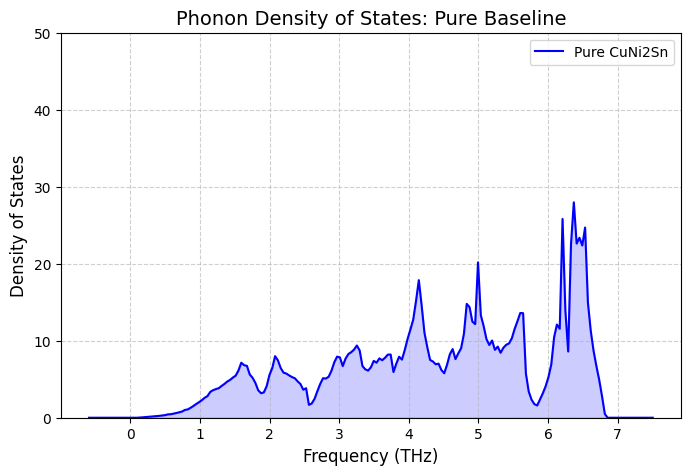

In [11]:
from matcalc import PhononCalc
import matplotlib.pyplot as plt

# 1. Initialize for the pure structure
phonon_calc = PhononCalc(
    calculator_pbe,
    supercell_matrix=((2, 0, 0), (0, 2, 0), (0, 0, 2)),
    relax_structure=False
)

print("Calculating Phonon Data for Pure CuNi2Sn...")
pure_phonon_data = phonon_calc.calc(final_structure_pbe)

# 2. Access the Phonopy object
ph = pure_phonon_data["phonon"]

# 3. Trigger the DOS calculation (Fixes the AttributeError)
# We use a mesh of 20x20x20
ph.run_mesh([20, 20, 20])
ph.run_total_dos()

# 4. Extract frequencies and densities
# get_total_dos_dict() returns a dictionary with 'frequency-points' and 'total-dos'
dos_dict = ph.get_total_dos_dict()
freqs = dos_dict['frequency_points']
densities = dos_dict['total_dos']

# 5. Visualization for Paper
plt.figure(figsize=(8, 5))
plt.plot(freqs, densities, color='blue', label='Pure CuNi2Sn')
plt.fill_between(freqs, densities, color='blue', alpha=0.2)
plt.ylim(0, 50)
plt.title("Phonon Density of States: Pure Baseline", fontsize=14)
plt.xlabel("Frequency (THz)", fontsize=12)
plt.ylabel("Density of States", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [12]:
# 1. Start with a fresh copy of your pure optimized CuNi2Sn structure
sac_al_18_75 = final_structure_pbe.copy()

# 2. Replace THREE sites with Al to reach 18.75% concentration
# We use indices 12 (Sn), 0 (Cu), and 4 (Ni) to keep the Al atoms separated
sac_al_18_75.replace(12, "Al")
sac_al_18_75.replace(0, "Al")
sac_al_18_75.replace(4, "Al")

print(f"Created 18.75% Al-doped structure: {sac_al_18_75.formula}")

# 3. High-Precision Relaxation
# We use the global relax_calc with fmax=0.001 for publication consistency
print("Starting high-precision optimization for 18.75% Al...")
relax_results_18_75 = relax_calc.calc(sac_al_18_75)
opt_struct_18_75 = relax_results_18_75["final_structure"]

print(f"18.75% Optimized Energy: {relax_results_18_75['energy']:.4f} eV")

Created 18.75% Al-doped structure: Al3 Cu3 Ni7 Sn3
Starting high-precision optimization for 18.75% Al...
18.75% Optimized Energy: -75.2992 eV


In [13]:
# 4. Calculate Elastic Moduli for the new concentration
elastic_results_18_75 = elastic_calc.calc(opt_struct_18_75)
multiplier_GPa = 160.2176621

bulk_18_75 = elastic_results_18_75['bulk_modulus_vrh'] * multiplier_GPa
shear_18_75 = elastic_results_18_75['shear_modulus_vrh'] * multiplier_GPa

print(f"--- 18.75% Al Doping Results ---")
print(f"Bulk Modulus: {bulk_18_75:.2f} GPa")
print(f"Shear Modulus: {shear_18_75:.2f} GPa")

# Monitor Pugh's Ratio for the brittleness argument
print(f"Pugh's Ratio (G/B): {shear_18_75 / bulk_18_75:.3f}")

--- 18.75% Al Doping Results ---
Bulk Modulus: 128.20 GPa
Shear Modulus: 39.94 GPa
Pugh's Ratio (G/B): 0.312


/tmp/ipykernel_1278/220927834.py:2: RuntimeWarning: Elastic strain-stress fits have mean R²=0.7134 below r2_min=0.95. The elastic tensor may be unreliable; consider smaller |strains|, more strain points, or enabling relax_deformed_structures.
  elastic_results_18_75 = elastic_calc.calc(opt_struct_18_75)


/usr/local/lib/python3.13/dist-packages/matcalc/_phonon.py:214: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [ 0.00000,  1.00000,  0.00000]
  [ 0.00000,  0.00000, -1.00000]
  [-1.00000, -0.00000,  0.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  phonon = phonopy.Phonopy(cell, supercell_matrix=supercell_matrix, symprec=self.symprec, primitive_matrix="auto")


Calculating Phonon Data for 18.75% Al-Doped CuNi2Sn...


/tmp/ipykernel_1278/1244644822.py:15: DeprecationWarning: get_total_dos_dict() is deprecated. Use the total_dos property to access the TotalDos result object; its frequency_points and dos attributes replace the dict keys.
  dos_18_75 = ph_18_75.get_total_dos_dict()


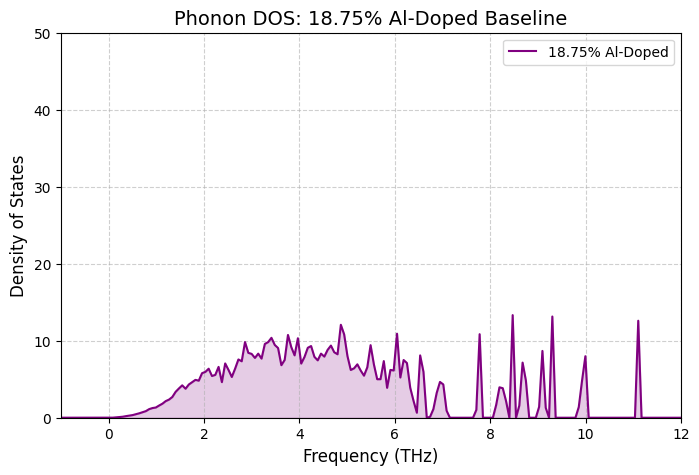

In [14]:
# 5. Initialize Phonon Calculator (2x2x2 supercell)
phonon_calc_18_75 = PhononCalc(
    calculator_pbe,
    supercell_matrix=((2, 0, 0), (0, 2, 0), (0, 0, 2)),
    relax_structure=False
)

print("Calculating Phonon Data for 18.75% Al-Doped CuNi2Sn...")
phonon_data_18_75 = phonon_calc_18_75.calc(opt_struct_18_75)
ph_18_75 = phonon_data_18_75["phonon"]

# Run DOS with high-mesh resolution
ph_18_75.run_mesh([20, 20, 20])
ph_18_75.run_total_dos()
dos_18_75 = ph_18_75.get_total_dos_dict()

# Visualization
plt.figure(figsize=(8, 5))
plt.plot(dos_18_75['frequency_points'], dos_18_75['total_dos'], color='purple', label='18.75% Al-Doped')
plt.fill_between(dos_18_75['frequency_points'], dos_18_75['total_dos'], color='purple', alpha=0.2)
plt.ylim(0, 50)
plt.xlim(-1, 12)
plt.title("Phonon DOS: 18.75% Al-Doped Baseline", fontsize=14)
plt.xlabel("Frequency (THz)", fontsize=12)
plt.ylabel("Density of States", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [15]:
import numpy as np

# Extract Thermodynamic Stability for 18.75% Al at Harsh Environment (473K)
ph_18_75.run_thermal_properties(t_step=5, t_max=600, t_min=0)
tp_18_75 = ph_18_75.get_thermal_properties_dict()
num_atoms = 16

# Use np to find the index closest to your target temperature (473K)
idx_473 = (np.abs(tp_18_75['temperatures'] - 473)).argmin()

# Apply the normalization factor to the target indexed outputs
normalized_free_energy = tp_18_75['free_energy'][idx_473] / num_atoms
normalized_entropy = tp_18_75['entropy'][idx_473] / num_atoms

print(f"--- 18.75% Al THERMODYNAMICS (NORMALIZED PER ATOM) ---")
print(f"Free Energy at 473K: {normalized_free_energy:.4f} kJ/mol·atom")
print(f"Entropy at 473K: {normalized_entropy:.4f} J/K/mol·atom")

--- 18.75% Al THERMODYNAMICS (NORMALIZED PER ATOM) ---
Free Energy at 473K: -9.7244 kJ/mol·atom
Entropy at 473K: 46.0317 J/K/mol·atom


/tmp/ipykernel_1278/3026963460.py:5: DeprecationWarning: get_thermal_properties_dict() is deprecated. Use the thermal_properties property to access the ThermalProperties result object; its temperatures, free_energy, entropy, and heat_capacity attributes replace the dict keys.
  tp_18_75 = ph_18_75.get_thermal_properties_dict()


In [16]:
# ============================================================
# INSPECT MATCALC / MATGL MD SUPPORT
# ============================================================

import inspect

print("=" * 70)
print("MATCALC MD-RELATED FUNCTIONS")
print("=" * 70)

for name in dir(matcalc):
    if any(x in name.lower() for x in [
        "md", "molecular", "nvt", "npt", "trajectory"
    ]):
        print(name)

print("\n" + "=" * 70)
print("ASE MD MODULES")
print("=" * 70)

import ase.md

for name in dir(ase.md):
    if not name.startswith("_"):
        print(name)

MATCALC MD-RELATED FUNCTIONS
LAMMPSMDCalc
MDCalc
_md

ASE MD MODULES
Andersen
Bussi
IsotropicMTKNPT
Langevin
MDLogger
MTKNPT
MaskedMTKNPT
NoseHooverChainNVT
VelocityVerlet
andersen
bussi
langevin
logger
md
melchionna
nose_hoover_chain
npt
nptberendsen
nvtberendsen
thermalize_momenta
velocitydistribution
verlet


In [17]:
print(final_structure_pbe)
print("Number of atoms:", len(final_structure_pbe))
print("Formula:", final_structure_pbe.formula)
print("Volume:", final_structure_pbe.volume)

Full Formula (Cu4 Ni8 Sn4)
Reduced Formula: CuNi2Sn
abc   :   5.981720   5.982937   5.984348
angles:  90.036519  90.032494  89.948502
pbc   :       True       True       True
Sites (16)
  #  SP            a          b         c
---  ----  ---------  ---------  --------
  0  Cu    -0.006963   9.2e-05   1.0109
  1  Cu     0.996426   0.494977  0.505733
  2  Cu     0.48835   -0.006325  0.502066
  3  Cu     0.499333   0.501408  0.999317
  4  Ni     0.237712   0.748524  0.757304
  5  Ni     0.246363   0.247328  0.756132
  6  Ni     0.251083   0.254905  0.249473
  7  Ni     0.242741   0.738653  0.251036
  8  Ni     0.746319   0.747069  0.257905
  9  Ni     0.736718   0.25002   0.257259
 10  Ni     0.744998   0.24029   0.750593
 11  Ni     0.754368   0.754523  0.750277
 12  Sn     0.000681   1.00214   0.497165
 13  Sn    -0.011289   0.494159  0.003101
 14  Sn     0.494121  -0.006602  0.004149
 15  Sn     0.495793   0.500597  0.510812
Number of atoms: 16
Formula: Cu4 Ni8 Sn4
Volume: 214.1691975

In [18]:
final_structure_pbe.to(filename="CuNi2Sn_relaxed.cif")

"# generated using pymatgen\ndata_CuNi2Sn\n_symmetry_space_group_name_H-M   'P 1'\n_cell_length_a   5.98171967\n_cell_length_b   5.98293681\n_cell_length_c   5.98434841\n_cell_angle_alpha   90.03651851\n_cell_angle_beta   90.03249377\n_cell_angle_gamma   89.94850187\n_symmetry_Int_Tables_number   1\n_chemical_formula_structural   CuNi2Sn\n_chemical_formula_sum   'Cu4 Ni8 Sn4'\n_cell_volume   214.16919751\n_cell_formula_units_Z   4\nloop_\n _symmetry_equiv_pos_site_id\n _symmetry_equiv_pos_as_xyz\n  1  'x, y, z'\nloop_\n _atom_site_type_symbol\n _atom_site_label\n _atom_site_symmetry_multiplicity\n _atom_site_fract_x\n _atom_site_fract_y\n _atom_site_fract_z\n _atom_site_occupancy\n  Cu  Cu0  1  -0.00696304  0.00009248  1.01089606  1\n  Cu  Cu1  1  0.99642556  0.49497662  0.50573254  1\n  Cu  Cu2  1  0.48834980  -0.00632538  0.50206608  1\n  Cu  Cu3  1  0.49933299  0.50140802  0.99931710  1\n  Ni  Ni4  1  0.23771182  0.74852361  0.75730358  1\n  Ni  Ni5  1  0.24636262  0.24732760  0.756

In [19]:
final_structure_18_75 = relax_results_18_75["final_structure"]

final_structure_18_75.to(filename="CuNi2Sn_18.75Al_relaxed.cif")

print("18.75% relaxed structure saved.")
print(final_structure_18_75)

18.75% relaxed structure saved.
Full Formula (Al3 Cu3 Ni7 Sn3)
Reduced Formula: Al3Cu3Ni7Sn3
abc   :   6.027612   6.032516   5.994591
angles:  89.705428  90.308903  90.569044
pbc   :       True       True       True
Sites (16)
  #  SP            a          b         c
---  ----  ---------  ---------  --------
  0  Al    -0.007319   0.001268  1.02293
  1  Cu     0.990082   0.470211  0.50149
  2  Cu     0.51257   -1e-05     0.510648
  3  Cu     0.481417   0.515009  0.988667
  4  Al     0.21333    0.768136  0.700561
  5  Ni     0.231153   0.211238  0.75559
  6  Ni     0.25039    0.232281  0.254429
  7  Ni     0.224272   0.767     0.291237
  8  Ni     0.762714   0.755047  0.265983
  9  Ni     0.732714   0.247096  0.230442
 10  Ni     0.755702   0.234888  0.776769
 11  Ni     0.794394   0.764206  0.745421
 12  Al    -0.037611   1.04151   0.484531
 13  Sn     0.00469    0.496192  0.018117
 14  Sn     0.495517  -0.024295  0.00916
 15  Sn     0.512737   0.48198   0.507242


In [20]:
# Check the relaxed 18.75% structure and TensorNet calculator

print("Number of atoms:", len(opt_struct_18_75))
print("Chemical formula:", opt_struct_18_75.composition.formula)

print("\nStructure type:")
print(type(opt_struct_18_75))

print("\nCalculator:")
print(calculator_pbe)

print("\nCalculator type:")
print(type(calculator_pbe))

print("\nPotential/model:")
print(calculator_pbe.potential.model)

Number of atoms: 16
Chemical formula: Al3 Cu3 Ni7 Sn3

Structure type:
<class 'pymatgen.core.structure.Structure'>

Calculator:

Calculator type:
<class 'matgl.ext.ase.PESCalculator'>

Potential/model:
TensorNet(
  (bond_expansion): BondExpansion(
    (rbf): SphericalBesselFunction()
  )
  (activation): SiLU()
  (tensor_embedding): TensorEmbedding(
    (distance_proj1): Linear(in_features=3, out_features=128, bias=True)
    (distance_proj2): Linear(in_features=3, out_features=128, bias=True)
    (distance_proj3): Linear(in_features=3, out_features=128, bias=True)
    (emb): Embedding(89, 128)
    (emb2): Linear(in_features=256, out_features=128, bias=True)
    (act): SiLU()
    (linears_tensor): ModuleList(
      (0-2): 3 x Linear(in_features=128, out_features=128, bias=False)
    )
    (linears_scalar): ModuleList(
      (0): Linear(in_features=128, out_features=256, bias=True)
      (1): Linear(in_features=256, out_features=384, bias=True)
    )
    (init_norm): LayerNorm((128,), eps

In [21]:
# ============================================================
# Convert relaxed 18.75% Al structure to ASE and test MD setup
# ============================================================

from pymatgen.io.ase import AseAtomsAdaptor
from ase import units
from ase.md.langevin import Langevin
from ase.md import MDLogger
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
import numpy as np

# Convert pymatgen Structure -> ASE Atoms
atoms_18_75 = AseAtomsAdaptor.get_atoms(opt_struct_18_75)

# Attach the SAME TensorNet calculator used in your calculations
atoms_18_75.calc = calculator_pbe

print("ASE atoms:", len(atoms_18_75))
print("Formula:", atoms_18_75.get_chemical_formula())
print("Periodic boundary conditions:", atoms_18_75.pbc)
print("Cell:")
print(atoms_18_75.cell)

# Check that the calculator can actually evaluate the relaxed structure
energy = atoms_18_75.get_potential_energy()

print("\nPotential energy:", energy, "eV")
print("Energy per atom:", energy / len(atoms_18_75), "eV/atom")

# Initialize velocities at 473 K
temperature = 473.0

MaxwellBoltzmannDistribution(
    atoms_18_75,
    temperature_K=temperature
)

print("\nMD setup successful.")
print("Target temperature:", temperature, "K")

ASE atoms: 16
Formula: Al3Cu3Ni7Sn3
Periodic boundary conditions: [ True  True  True]
Cell:
Cell([[6.027515501313767, -0.0299191884978303, -0.016192469304468365], [-0.02992801854540082, 6.032422001000131, 0.015450028129631706], [-0.016139195619344685, 0.015386941354055312, 5.994549861444416]])

Potential energy: -75.29924774169922 eV
Energy per atom: -4.706202983856201 eV/atom

MD setup successful.
Target temperature: 473.0 K


/tmp/ipykernel_1278/1333091704.py:33: DeprecationWarning: Use thermalize_momenta
  MaxwellBoltzmannDistribution(


In [22]:
# ============================================================
# BUILD 2×2×2 SUPERCELL FOR 18.75% Al MD
# ============================================================

from ase.io import write

# Start from the relaxed 16-atom structure
atoms_super = atoms_18_75.copy()

# Create 2×2×2 supercell
atoms_super *= (2, 2, 2)

# Attach the same TensorNet calculator
atoms_super.calc = calculator_pbe

print("Supercell created successfully.")
print("Number of atoms:", len(atoms_super))
print("Chemical formula:", atoms_super.get_chemical_formula())
print("PBC:", atoms_super.pbc)

print("\nSupercell dimensions:")
print(atoms_super.cell)

# Check initial potential energy
energy_super = atoms_super.get_potential_energy()

print("\nInitial potential energy:", energy_super, "eV")
print("Energy per atom:", energy_super / len(atoms_super), "eV/atom")

# Save the 128-atom structure
write(
    "CuNi2Sn_18.75Al_2x2x2_relaxed.cif",
    atoms_super
)

print("\nSaved:")
print("CuNi2Sn_18.75Al_2x2x2_relaxed.cif")

Supercell created successfully.
Number of atoms: 128
Chemical formula: Al24Cu24Ni56Sn24
PBC: [ True  True  True]

Supercell dimensions:
Cell([[12.055031002627533, -0.0598383769956606, -0.03238493860893673], [-0.05985603709080164, 12.064844002000262, 0.03090005625926341], [-0.03227839123868937, 0.030773882708110625, 11.989099722888833]])

Initial potential energy: -602.3939819335938 eV
Energy per atom: -4.706202983856201 eV/atom

Saved:
CuNi2Sn_18.75Al_2x2x2_relaxed.cif


In [35]:
import numpy as np
import time

from ase import units
from ase.md.langevin import Langevin
from ase.md import MDLogger
from ase.io import Trajectory
from ase.md.velocitydistribution import (
    MaxwellBoltzmannDistribution,
    Stationary
)

# ============================================================
# 1. Fresh copy for MD
# ============================================================

md_atoms_18_75 = atoms_super.copy()
md_atoms_18_75.calc = calculator_pbe


# ============================================================
# 2. Fixed random seed
# ============================================================

seed = 3003
rng = np.random.RandomState(seed)


# ============================================================
# 3. Temperature and initial velocities
# ============================================================

temperature_K = 473

MaxwellBoltzmannDistribution(
    md_atoms_18_75,
    temperature_K=temperature_K,
    rng=rng
)

Stationary(md_atoms_18_75)


# ============================================================
# 4. MD parameters
# ============================================================

timestep = 1.0 * units.fs
friction = 0.01 / units.fs


# ============================================================
# 5. Langevin NVT
# ============================================================

dyn = Langevin(
    md_atoms_18_75,
    timestep=timestep,
    temperature_K=temperature_K,
    friction=friction,
    fixcm=False,
    rng=rng
)


# ============================================================
# 6. Unique output filenames
# ============================================================

traj_file = f"CuNi2Sn_18.75Al_2x2x2_MD_2ps_seed{seed}.traj"
log_file = f"CuNi2Sn_18.75Al_2x2x2_MD_2ps_seed{seed}.log"


# ============================================================
# 7. Save trajectory
# ============================================================

traj = Trajectory(
    traj_file,
    "w",
    md_atoms_18_75
)

dyn.attach(traj.write, interval=10)


# ============================================================
# 8. Save MD log
# ============================================================

logger = MDLogger(
    dyn,
    md_atoms_18_75,
    log_file,
    header=True,
    stress=False,
    peratom=False,
    mode="w"
)

dyn.attach(logger, interval=10)


# ============================================================
# 9. Run 2 ps = 2000 steps
# ============================================================

start_time = time.time()

dyn.run(2000)

elapsed = time.time() - start_time


# ============================================================
# 10. Close trajectory
# ============================================================

traj.close()


# ============================================================
# 11. Report
# ============================================================

print("MD completed")
print("Composition: 18.75 at.% Al")
print("Random seed:", seed)
print("Steps: 2000")
print("Timestep: 1 fs")
print("Total simulation time: 2 ps")
print("Number of atoms:", len(md_atoms_18_75))
print(f"Runtime: {elapsed/60:.2f} min")
print("Trajectory:", traj_file)
print("Log:", log_file)

/tmp/ipykernel_1278/1086654025.py:35: DeprecationWarning: Use thermalize_momenta
  MaxwellBoltzmannDistribution(


MD completed
Composition: 18.75 at.% Al
Random seed: 3003
Steps: 2000
Timestep: 1 fs
Total simulation time: 2 ps
Number of atoms: 128
Runtime: 29.52 min
Trajectory: CuNi2Sn_18.75Al_2x2x2_MD_2ps_seed3003.traj
Log: CuNi2Sn_18.75Al_2x2x2_MD_2ps_seed3003.log


In [36]:
from ase.io import read
import numpy as np

# Load trajectory
traj = read(
    "CuNi2Sn_18.75Al_2x2x2_MD_2ps_seed3003.traj",
    index=":"
)

print("Number of frames:", len(traj))
print("Atoms per frame:", len(traj[0]))

# ------------------------------------------------------------
# Temperature analysis
# ------------------------------------------------------------
temperatures = []

for atoms in traj:
    temperatures.append(atoms.get_temperature())

temperatures = np.array(temperatures)

print("\nTemperature statistics:")
print(f"Mean temperature: {temperatures.mean():.2f} K")
print(f"Std. deviation:   {temperatures.std():.2f} K")
print(f"Minimum:          {temperatures.min():.2f} K")
print(f"Maximum:          {temperatures.max():.2f} K")

# ------------------------------------------------------------
# Potential energy analysis
# ------------------------------------------------------------
energies = np.array([
    atoms.get_potential_energy()
    for atoms in traj
])

print("\nPotential energy statistics:")
print(f"Initial: {energies[0]:.6f} eV")
print(f"Final:   {energies[-1]:.6f} eV")
print(f"Minimum: {energies.min():.6f} eV")
print(f"Maximum: {energies.max():.6f} eV")

# ------------------------------------------------------------
# Basic structural displacement
# ------------------------------------------------------------
initial_positions = traj[0].get_positions()

final_positions = traj[-1].get_positions()

raw_displacement = final_positions - initial_positions

rms_displacement = np.sqrt(
    np.mean(np.sum(raw_displacement**2, axis=1))
)

print("\nRaw RMS displacement:")
print(f"{rms_displacement:.6f} Å")

print("\nTrajectory inspection completed.")

Number of frames: 201
Atoms per frame: 128

Temperature statistics:
Mean temperature: 457.96 K
Std. deviation:   45.53 K
Minimum:          265.79 K
Maximum:          553.91 K

Potential energy statistics:
Initial: -602.393982 eV
Final:   -594.064697 eV
Minimum: -602.393982 eV
Maximum: -593.822998 eV

Raw RMS displacement:
0.321111 Å

Trajectory inspection completed.


Time-origin averaged MSD
------------------------
Frames: 201
Atoms: 128
Total trajectory time: 2.00 ps
MSD at 0.25 ps: 0.082707 Å²
MSD at 0.50 ps: 0.095823 Å²
MSD at 0.75 ps: 0.108686 Å²
MSD at 1.00 ps: 0.105958 Å²
MSD at 1.50 ps: 0.110578 Å²
MSD at 2.00 ps: 0.103112 Å²


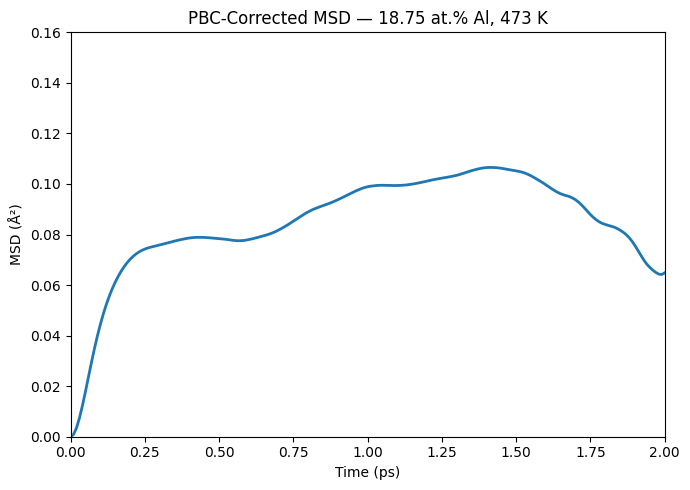

In [37]:
from ase.io import read
import numpy as np
import matplotlib.pyplot as plt

traj = read("CuNi2Sn_18.75Al_2x2x2_MD_2ps_seed3003.traj", index=":")

nframes = len(traj)
natoms = len(traj[0])
dt_ps = 0.01  # 10 fs between saved frames

# -----------------------------
# Unwrap trajectory
# -----------------------------
frac = np.array([
    atoms.get_scaled_positions(wrap=False)
    for atoms in traj
])

frac_unwrapped = np.zeros_like(frac)
frac_unwrapped[0] = frac[0]

for i in range(1, nframes):
    delta = frac[i] - frac[i-1]
    delta -= np.round(delta)
    frac_unwrapped[i] = frac_unwrapped[i-1] + delta

cell = traj[0].cell.array

cart = np.einsum("fai,ij->faj", frac_unwrapped, cell)

# -----------------------------
# Time-origin averaged MSD
# -----------------------------
max_lag = nframes

msd_avg = np.zeros(max_lag)

for lag in range(1, max_lag):
    displacements = cart[lag:] - cart[:-lag]
    msd_avg[lag] = np.mean(
        np.sum(displacements**2, axis=2)
    )

time_lag_ps = np.arange(max_lag) * dt_ps

# -----------------------------
# Print selected values
# -----------------------------
def get_msd(t_ps):
    idx = int(round(t_ps / dt_ps))
    return msd_avg[idx]

print("Time-origin averaged MSD")
print("------------------------")
print(f"Frames: {nframes}")
print(f"Atoms: {natoms}")
print(f"Total trajectory time: {(nframes-1)*dt_ps:.2f} ps")
print(f"MSD at 0.25 ps: {get_msd(0.25):.6f} Å²")
print(f"MSD at 0.50 ps: {get_msd(0.50):.6f} Å²")
print(f"MSD at 0.75 ps: {get_msd(0.75):.6f} Å²")
print(f"MSD at 1.00 ps: {get_msd(1.00):.6f} Å²")
print(f"MSD at 1.50 ps: {get_msd(1.50):.6f} Å²")
print(f"MSD at 2.00 ps: {get_msd(2.00):.6f} Å²")

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
plt.figure(figsize=(7, 5))

plt.plot(
    time_ps,
    msd,
    linewidth=2
)

plt.xlabel("Time (ps)")
plt.ylabel("MSD (Å²)")
plt.title(
    "PBC-Corrected MSD — 18.75 at.% Al, 473 K"
)

# Fixed scale for comparison across all compositions
plt.xlim(0, 2.0)
plt.ylim(0, 0.16)

plt.tight_layout()
plt.show()

Species-resolved time-origin averaged MSD
------------------------------------------

Al:
  Number of atoms: 24
  MSD at 0.25 ps: 0.070881 Å²
  MSD at 0.50 ps: 0.088127 Å²
  MSD at 0.75 ps: 0.099089 Å²
  MSD at 1.00 ps: 0.102753 Å²
  MSD at 1.25 ps: 0.100585 Å²
  MSD at 1.50 ps: 0.094550 Å²
  MSD at 1.75 ps: 0.092402 Å²
  MSD at 2.00 ps: 0.071654 Å²

Cu:
  Number of atoms: 24
  MSD at 0.25 ps: 0.085814 Å²
  MSD at 0.50 ps: 0.098559 Å²
  MSD at 0.75 ps: 0.111448 Å²
  MSD at 1.00 ps: 0.107009 Å²
  MSD at 1.25 ps: 0.112604 Å²
  MSD at 1.50 ps: 0.117684 Å²
  MSD at 1.75 ps: 0.128102 Å²
  MSD at 2.00 ps: 0.106357 Å²

Ni:
  Number of atoms: 56
  MSD at 0.25 ps: 0.090553 Å²
  MSD at 0.50 ps: 0.104602 Å²
  MSD at 0.75 ps: 0.118584 Å²
  MSD at 1.00 ps: 0.113627 Å²
  MSD at 1.25 ps: 0.119254 Å²
  MSD at 1.50 ps: 0.119085 Å²
  MSD at 1.75 ps: 0.131632 Å²
  MSD at 2.00 ps: 0.115449 Å²

Sn:
  Number of atoms: 24
  MSD at 0.25 ps: 0.073118 Å²
  MSD at 0.50 ps: 0.080300 Å²
  MSD at 0.75 ps: 0.092424 

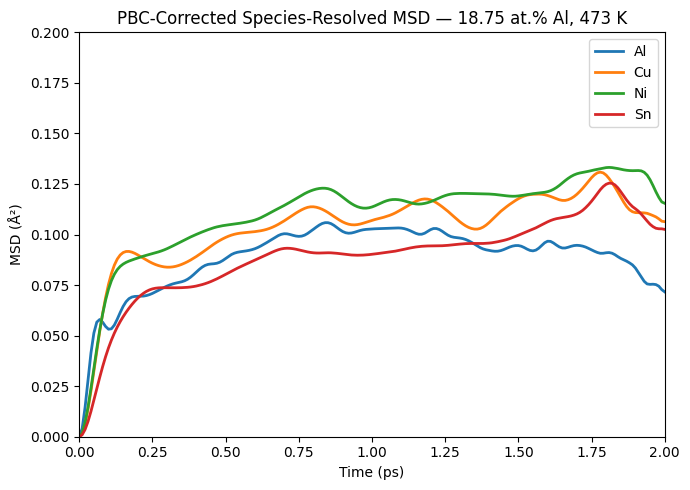

In [38]:
from ase.io import read
import numpy as np
import matplotlib.pyplot as plt

traj = read("CuNi2Sn_18.75Al_2x2x2_MD_2ps_seed3003.traj", index=":")

nframes = len(traj)
natoms = len(traj[0])
dt_ps = 0.01

# -----------------------------
# Unwrap trajectory
# -----------------------------
frac = np.array([
    atoms.get_scaled_positions(wrap=False)
    for atoms in traj
])

frac_unwrapped = np.zeros_like(frac)
frac_unwrapped[0] = frac[0]

for i in range(1, nframes):
    delta = frac[i] - frac[i-1]
    delta -= np.round(delta)
    frac_unwrapped[i] = frac_unwrapped[i-1] + delta

cell = traj[0].cell.array
cart = np.einsum("fai,ij->faj", frac_unwrapped, cell)

# -----------------------------
# Species masks
# -----------------------------
symbols = np.array(traj[0].get_chemical_symbols())

species_list = ["Al", "Cu", "Ni", "Sn"]

# -----------------------------
# Time-origin averaged MSD
# -----------------------------
max_lag = nframes

species_msd = {}

for species in species_list:

    mask = symbols == species

    msd = np.zeros(max_lag)

    for lag in range(1, max_lag):

        displacement = cart[lag:, mask, :] - cart[:-lag, mask, :]

        msd[lag] = np.mean(
            np.sum(displacement**2, axis=2)
        )

    species_msd[species] = msd

time_lag_ps = np.arange(max_lag) * dt_ps

# -----------------------------
# Print values
# -----------------------------
print("Species-resolved time-origin averaged MSD")
print("------------------------------------------")

for species in species_list:

    msd = species_msd[species]

    print(f"\n{species}:")
    print(f"  Number of atoms: {np.sum(symbols == species)}")
    print(f"  MSD at 0.25 ps: {msd[int(0.25/dt_ps)]:.6f} Å²")
    print(f"  MSD at 0.50 ps: {msd[int(0.50/dt_ps)]:.6f} Å²")
    print(f"  MSD at 0.75 ps: {msd[int(0.75/dt_ps)]:.6f} Å²")
    print(f"  MSD at 1.00 ps: {msd[int(1.00/dt_ps)]:.6f} Å²")
    print(f"  MSD at 1.25 ps: {msd[int(1.25/dt_ps)]:.6f} Å²")
    print(f"  MSD at 1.50 ps: {msd[int(1.50/dt_ps)]:.6f} Å²")
    print(f"  MSD at 1.75 ps: {msd[int(1.75/dt_ps)]:.6f} Å²")
    print(f"  MSD at 2.00 ps: {msd[int(2.00/dt_ps)]:.6f} Å²")


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
plt.figure(figsize=(7, 5))

for species in species_list:
    plt.plot(
        time_ps,
        species_msd[species],
        label=species,
        linewidth=2
    )

plt.xlabel("Time (ps)")
plt.ylabel("MSD (Å²)")
plt.title(
    "PBC-Corrected Species-Resolved MSD — "
    "18.75 at.% Al, 473 K"
)

# Fixed scale for comparison across all compositions
plt.xlim(0, 2.0)
plt.ylim(0, 0.20)

plt.legend()
plt.tight_layout()
plt.show()